## Curva Receiver Operator Characteristic (ROC)

### **O que é a curva ROC?**

A curva ROC é um gráfico usado para avaliar o desempenho de modelos de classificação binária. Ela mostra como o modelo se comporta ao variar o limiar de decisão (threshold).

A curva plota duas métricas, sendo elas a 
$TPR = \frac{positivos \space verdadeiros}{positivos \space verdadeiros + negativos \space falsos}$ (taxa de positvos verdadeiros) e a $FPR = \frac{positivos \space falsos}{positivos \space falsos + negativos \space verdadeiros}$(taxa de positivos falsos). 

A curva consiste no cálculo dessas métricas para cada variação de $\lambda$ (threshold), que basicamente dita quando consideramos, ou não, os valores preditos serem de uma determinada classe.

### **Como interpretar uma curva ROC?**

A métrica mais usada para avaliar se um modelo é bom é a AUC (área abaixo da curva). Dessa forma, sempre começamos no ponto (FPR=0, TPR=0) - ou seja, classificamos nenhum ponto como positivo - e sempre terminamos (FPR=1, TPR=1) - ou seja, classificamos todos os pontos como positivos. O ponto ideal seria (FPR=0, TPR=1), em que acertamos todas as classificações, dessa forma, quanto mais próxima a curva desse ponto e quanto mais próximo de 1 o valor de AUC for, melhor o modelo é.

Além disso, quando $AUC = 0.5$, podemos interpretar que o classificador faz um chute de probabilidade $1/2$ sobre a classe da amostra.

Apesar de ser mais comum no caso de classificação binária, a curva ROC pode ser usada no problema multiclasse, fazendo os mesmos cálculos supracitados, mas considerando os pares dois a dois de cada classe. Além disso, pode-se usar a métrica $AUC_{macro}$ que é a média das $AUCs$ dos pares anteriormente calculados.

Em problemas reais, costumamos calcular as diferentes formas de $AUC$ usando funções prontas de bibliotecas de Machine Learning.

### **Exemplo**

In [63]:
# Bibliotecas usadas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [64]:
# Carregando os dados
iris_dataset = load_iris(return_X_y=False, as_frame=False)
X = iris_dataset["data"]
y = iris_dataset["target"]
y = (y == 2).astype(int) # Tirando a classe 2 (deixando só 0 e 1)

In [65]:
# Separando em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Fazendo um modelo de regressão logística para obter o vetor de previsões da classe positiva
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)[:, 1]  # Pegando apenas as probabilidades da classe positiva

In [66]:
def get_fpr_tpr(predicted_values: np.array, true_labels: np.array, threshold: float) -> tuple[float, float]:
    
    # Transformando o array de predições de acordo com o threshold
    predicted_labels = (predicted_values >= threshold).astype(int)
    
    # Contando tp, fp, tn e fn
    tp = np.sum((predicted_labels == 1) & (true_labels == 1))
    fp = np.sum((predicted_labels == 1) & (true_labels == 0))
    tn = np.sum((predicted_labels == 0) & (true_labels == 0))
    fn = np.sum((predicted_labels == 0) & (true_labels == 1))
    
    # Calculating the fpr and the tpr
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        
    return fpr, tpr

In [67]:
def get_auc(predicted_values: np.array, true_labels: np.array) -> float:

    # Calculando a métrica AUC
    auc = roc_auc_score(true_labels, predicted_values)

    return auc

In [68]:
def plot_roc_curve(predicted_values: np.array, true_labels: np.array, thresholds: float, color: str="blue") -> None:
    
    # Inciando os conjuntos para armzenar o histórico de fpr e tpr
    roc_fpr, roc_tpr = set(), set()
    
    # Calculando o tpr e o fpr para cada threshold
    for threshold in thresholds:
        fpr, tpr = get_fpr_tpr(predicted_values, true_labels, threshold)
        roc_fpr.add((fpr, tpr))
    
    roc_fpr, roc_tpr = zip(*sorted(roc_fpr))
    
    # Plotando o gráfico
    plt.figure(figsize=(8, 6))
    plt.plot(roc_fpr, roc_tpr, label=f"AUC = {get_auc(predicted_values, true_labels):.3f}", color=color)
    plt.plot([0,1], [0,1], linestyle="--", color="yellow", label="AUC=0.5")
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    plt.legend()
    plt.grid()
    plt.show()

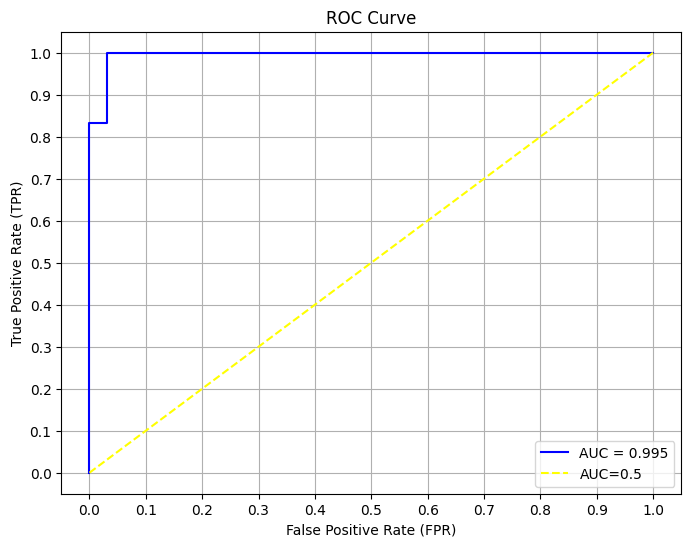

In [69]:
# Fazendo a curva ROC para o modelo de regressão logísitca
thresholds = np.linspace(0, 1, 50)
plot_roc_curve(y_pred, y_test, thresholds)